In [1]:
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from mplsoccer import VerticalPitch, FontManager, Sbopen
from highlight_text import fig_text# Get data
parser = Sbopen()
match_id = 3857283
df_event, _, _, _ = parser.event(3857283)  # Unpack all 4 returned DataFrames

# Filter Morocco pressure events
mask_morocco_pressure = (df_event.team_name == 'Belgium') & (df_event.type_name == 'Pressure')
df = df_event.loc[mask_morocco_pressure, ['x', 'y']]

In [2]:
# see the custom colormaps example for more ideas on setting colormaps
pearl_earring_cmap = LinearSegmentedColormap.from_list("Pearl Earring - 10 colors",
                                                       ['#15242e', '#4393c4'], N=10)

# fontmanager for google font (robotto)
robotto_regular = FontManager()

path_eff = [path_effects.Stroke(linewidth=3, foreground='black'),
            path_effects.Normal()]

Text(0.5, 1.0, 'belgium Heatmap in the full match')

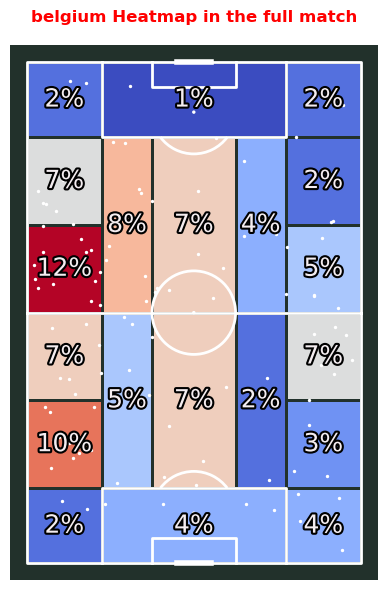

In [3]:
pitch = VerticalPitch(pitch_type='statsbomb', line_zorder=2,
                      pitch_color='#22312b', line_color='white')
# draw
fig, ax = pitch.draw(figsize=(4.125, 6))
bin_statistic = pitch.bin_statistic_positional(df.x, df.y, statistic='count',
                                               positional='full', normalize=True)
pitch.heatmap_positional(bin_statistic, ax=ax, cmap='coolwarm', edgecolors='#22312b')
pitch.scatter(df.x, df.y, c='white', s=2, ax=ax)
labels = pitch.label_heatmap(bin_statistic, color='#f4edf0', fontsize=18,
                             ax=ax, ha='center', va='center',
                             str_format='{:.0%}', path_effects=path_eff)
ax.set_title('belgium Heatmap in the full match', color='red', va='center', ha='center', fontsize=12,fontweight='bold',pad=20,loc='center')